In [1]:
import numpy as np
import pandas as pd
import scipy
import copy

import random

from src.simulation.domain.model import construct_well2, h_lim, betta_G_lim, construct_well
from src.simulation.service_layer.services import get_dict_for_data, build_plot, PlotData, Scale
from src.simulation.domain.meter import Meter, add_noise
from src.identification.domain.model import ident_values, identificate, get_data_by_slices, identificate_regul, \
    get_res_dict_for_ident, ident_values_nkt, identificate_nkt, ident_values_inflow, identificate_inflow
from src.identification.service_layer.services import calc_rsd_by_series, calc_bias_by_series, calc_error, calc_error_by_series

In [2]:
# Начальные условия
M_q = 0.5
epsilon = 0.00001
K_NUMBERS = 10420  # Количество точек моделирования
dt = 0.0001  # Суток

w_program1 = {
    1.010: 1.05,
    1.020: 0.8,
    1.030: 0.9}

w_program2 = {
    1.010: 1.09,
    1.020: 0.77,
    1.030: 0.95}

w_program3 = {
    1.010: 1.12,
    1.020: 0.74,
    1.030: 1.00}

well = construct_well2(p_R=21.5, agzu_on=False, p_L_change_on=False, nn1=0.8, nn2=0.9)
well.set_w_program(w_program3)


df = well.simulate(K_NUMBERS, dt, M_q, epsilon, get_dict_for_data())
df = pd.DataFrame(df)
df = df.iloc[10000:].reset_index(drop=True)
df['x_hours'] = df['x_hours'] - df['x_hours'].iloc[0]

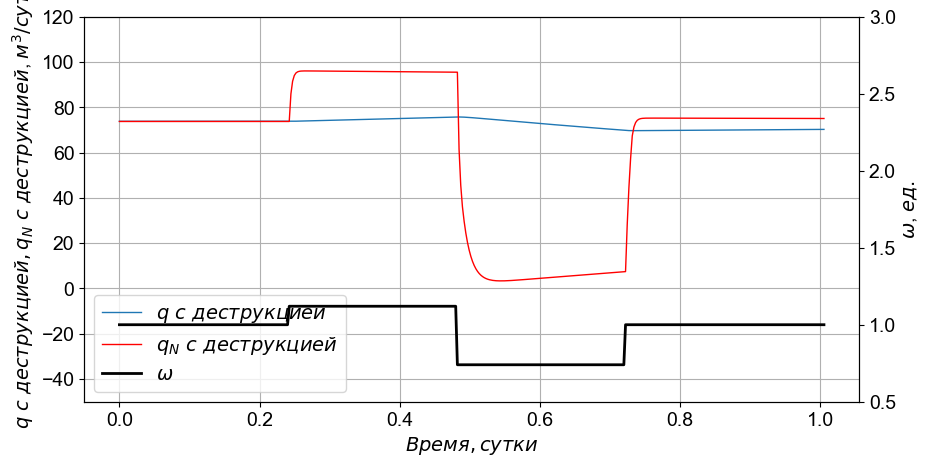

In [3]:
plot_data = [
             {'data': (
                PlotData(df['q'], '', 1, 'q\\ c\\ деструкцией'),
                PlotData(df['q_N'], 'r', 1, 'q_N\\ c\\ деструкцией'),
              ), 'x': df['x_hours'], 'y_scale': Scale(min=-50, max=120), 'dt': dt, 'mu': 'м^3/сут'},

             {'data': (
               PlotData(df['u'], 'k', 2, '\omega'),
               #PlotData(df['agzu'], 'g', 1, 'АГЗУ'),
              ), 'x': df['x_hours'], 'y_scale': Scale(min=0.5, max=3), 'dt': dt, 'mu': 'ед.'},
            ]

plot = build_plot(plot_data)
plot.show()

In [4]:
df.to_csv(
    'model_output_destruction.csv',
    sep=';',            # разделитель ; если открываете в Excel (RU)
    decimal=',',
)

In [5]:
well2 = construct_well2(agzu_on=False, p_L_change_on=False, nn1=1, nn2=1)
well2.set_w_program(w_program3)


df2 = well2.simulate(K_NUMBERS, dt, M_q, epsilon, get_dict_for_data())
df2 = pd.DataFrame(df2)
df2 = df2.iloc[10000:].reset_index(drop=True)

In [6]:
df2=df2.add_suffix('out')
df2.to_csv(
    'model_output.csv',
    sep=';',            # разделитель ; если открываете в Excel (RU)
    decimal=',',
)

In [7]:
meter = Meter(dt)
meter.noise_enable = True
meter.noise_amplitude = 0.1

ident_dt, ident_k, df_ident = meter.measure(df, quant_step=None, denominator=1)

In [8]:
df_ident=df_ident.add_suffix('_meas')
df_ident.to_csv(
    'model_measure.csv',
    sep=';',            # разделитель ; если открываете в Excel (RU)
    decimal=',',
)

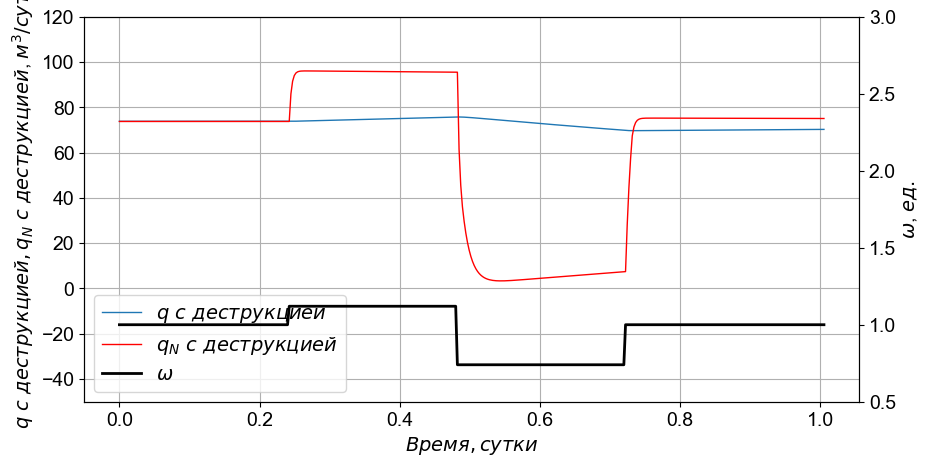

In [9]:
plot_data = [
             {'data': (
                PlotData(df['q'], '', 1, 'q\\ c\\ деструкцией'),
                PlotData(df['q_N'], 'r', 1, 'q_N\\ c\\ деструкцией'),
              ), 'x': df['x_hours'], 'y_scale': Scale(min=-50, max=120), 'dt': dt, 'mu': 'м^3/сут'},

             {'data': (
               PlotData(df['u'], 'k', 2, '\omega'),
               #PlotData(df['agzu'], 'g', 1, 'АГЗУ'),
              ), 'x': df['x_hours'], 'y_scale': Scale(min=0.5, max=3), 'dt': dt, 'mu': 'ед.'},
            ]

plot = build_plot(plot_data)
plot.show()

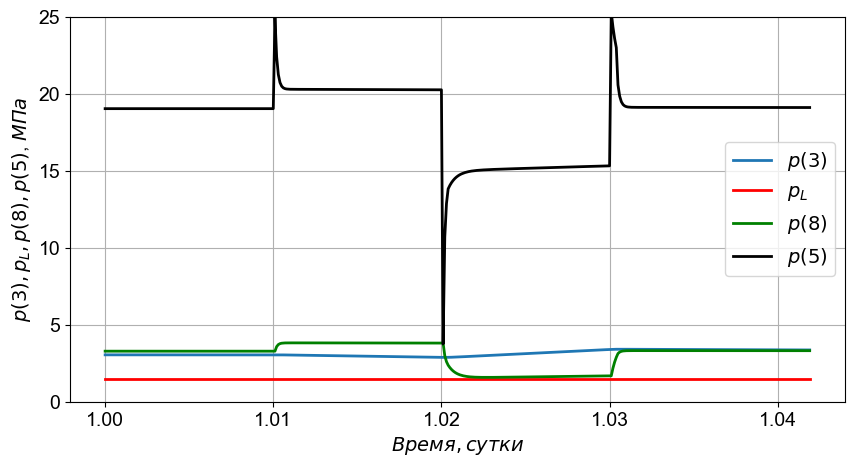

In [10]:
plot_data = [
            {'data': (
              PlotData(df['p_3'], '', 2, 'p(3)'),
              PlotData(df['p_L'], 'r', 2, 'p_L'),
              PlotData(df['p_8'], 'g', 2, 'p(8)'),
              PlotData(df['p_5'], 'k', 2, 'p(5)'),
              #PlotData(df_ident['p_3'], '', 1, 'p(3)'),
              #PlotData(df_ident['p_L'], 'r', 1, 'p_L'),
              #PlotData(df_ident['p_8'], 'g', 1, 'p(8)'),
              ), 'x': df['x'], 'y_scale': Scale(min=0, max=25), 'dt': dt, 'mu': 'МПа'},
]


plot = build_plot(plot_data)
plot.show()

In [11]:
meter = Meter(dt)
meter.noise_enable = True
meter.noise_amplitude = 0.02

ident_dt, ident_k, df_ident = meter.measure(df, quant_step=None, denominator=1)

calc_df = ident_values_nkt(ident_k, ident_dt, df_ident, well, filter_name=None)

b, squared_error_sum = identificate_nkt(calc_df, ident_k)
b

array([4.31986334, 0.7988036 , 0.88472277])

In [12]:
# Устойчивость идентификации

# Начальные условия
M_q = 0.5
epsilon = 0.00001
K_NUMBERS = 10420  # Количество точек моделирования
dt = 0.0001  # Суток


w_program1 = {
    1.010: 1.03,
    1.020: 0.83,
    1.030: 0.9
}

w_program2 = {
    1.010: 1.075,
    1.020: 0.785,
    1.030: 0.95
}

w_program3 = {
    1.010: 1.12,
    1.020: 0.74,
    1.030: 1.00
}

programs = [w_program1, w_program2, w_program3]

programs_num = len(programs)

experiment_num_max = 1

noise_list = arr = np.linspace(0, 0.1, 30)

noise_num = len(noise_list)

res = {'r_N': np.zeros((programs_num, noise_num, experiment_num_max)),
       'nn_1': np.zeros((programs_num, noise_num, experiment_num_max)),
       'nn_2': np.zeros((programs_num, noise_num, experiment_num_max)),
       }

data_frames = []

for p_num, program in enumerate(programs):

    well = construct_well2(p_R=21.5, agzu_on=False, p_L_change_on=False, nn1=0.8, nn2=0.9)
    well.set_w_program(program)


    df = well.simulate(K_NUMBERS, dt, M_q, epsilon, get_dict_for_data())
    df = pd.DataFrame(df)
    df = df.iloc[10000:].reset_index(drop=True)
    df['x_hours'] = df['x_hours'] - df['x_hours'].iloc[0]

    data_frames.append(df)

    meter = Meter(dt)
    meter.noise_enable = True


    for i, noise in enumerate(noise_list):
        for experiment_num in range(experiment_num_max):

            meter.noise_amplitude = noise

            ident_dt, ident_k, df_ident = meter.measure(df, quant_step=None, denominator=1)

            calc_df = ident_values_nkt(ident_k, ident_dt, df_ident, well, filter_name=None)

            b, squared_error_sum = identificate_nkt(calc_df, ident_k)

            res['r_N'][p_num, i, experiment_num] = b[0]
            res['nn_1'][p_num, i,experiment_num] = b[1]
            res['nn_2'][p_num, i, experiment_num] = b[2]

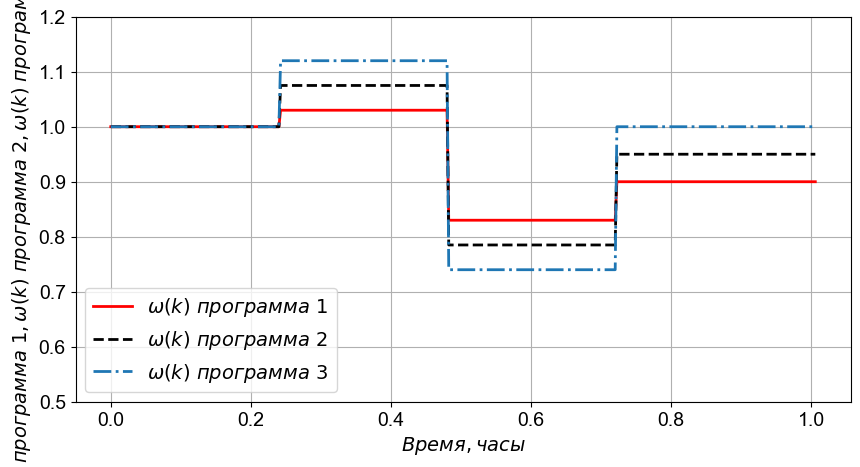

In [22]:
plot_data = [

             {'data': (
               PlotData(data_frames[0]['u'], 'r', 2, '\omega(k)\ программа\ 1'),
                 PlotData(data_frames[1]['u'], '--k', 2, '\omega(k)\ программа\ 2'),
                 PlotData(data_frames[2]['u'], '-.C0', 2, '\omega(k)\ программа\ 3'),
              ), 'x': df['x_hours'], 'y_scale': Scale(min=0.5, max=1.2), 'dt': dt, 'mu': 'ед.'},
            ]

plot = build_plot(plot_data, x_label='$Время, часы$')
plot.show()

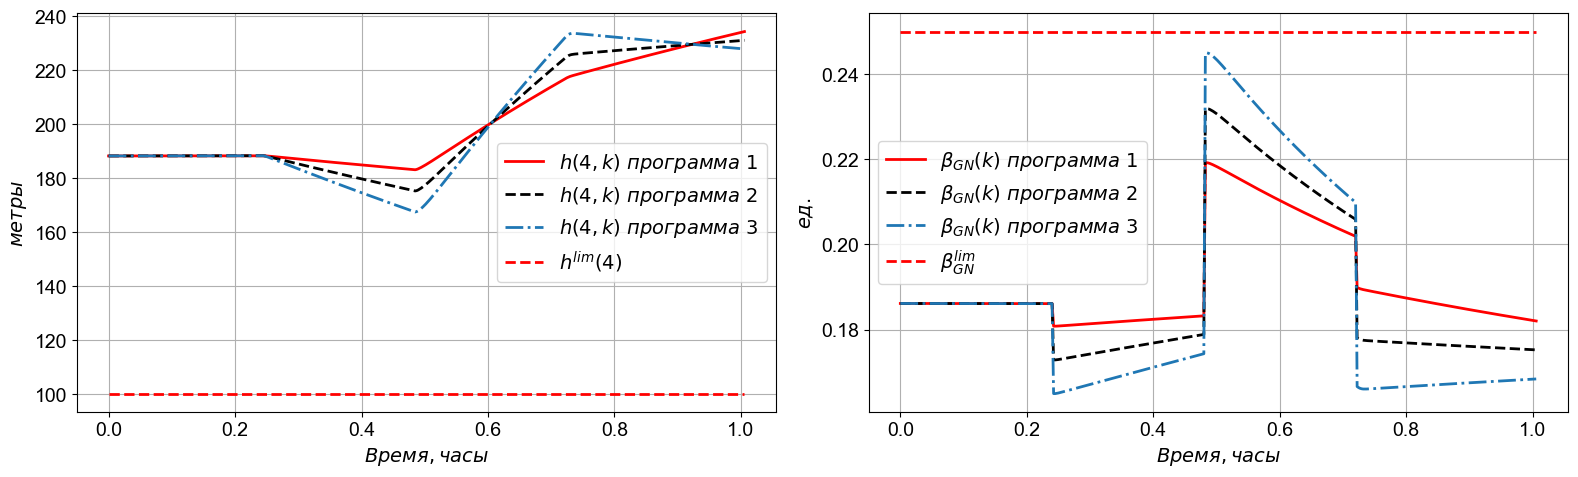

In [21]:
from matplotlib import pyplot as plt

points_num = len(df['x_hours'])

# Визуализация
plt.figure(figsize=(16, 5))

# График давления
plt.subplot(1, 2, 1)
plt.plot(df['x_hours'], data_frames[0]['h_4'], 'r', lw=2, label='$h(4,k)\ программа\ 1$')
plt.plot(df['x_hours'], data_frames[1]['h_4'], '--k', lw=2, label='$h(4,k)\ программа\ 2$')
plt.plot(df['x_hours'], data_frames[2]['h_4'], '-.C0', lw=2, label='$h(4,k)\ программа\ 3$')
plt.plot(df['x_hours'], [100]*points_num, '--r', lw=2, label='$h^{lim}(4)$')

plt.xlabel('$Время, часы$')
plt.ylabel('$метры$')
plt.legend()
plt.grid()


# График НЧ шума
plt.subplot(1, 2, 2)
plt.plot(df['x_hours'], data_frames[0]['betta_GN'], 'r', lw=2, label='$\\beta_{GN}(k)\ программа\ 1$')
plt.plot(df['x_hours'], data_frames[1]['betta_GN'], '--k', lw=2, label='$\\beta_{GN}(k)\ программа\ 2$')
plt.plot(df['x_hours'], data_frames[2]['betta_GN'], '-.C0', lw=2, label='$\\beta_{GN}(k)\ программа\ 3$')
plt.plot(df['x_hours'], [0.25]*points_num, '--r', lw=2, label='$\\beta_{GN}^{lim}$')

plt.xlabel('$Время, часы$')
plt.ylabel('$ед.$')
plt.legend()
plt.grid()
#plt.ylim(0, 0.8)



plt.tight_layout()
plt.show()

In [15]:
noise_list*=100

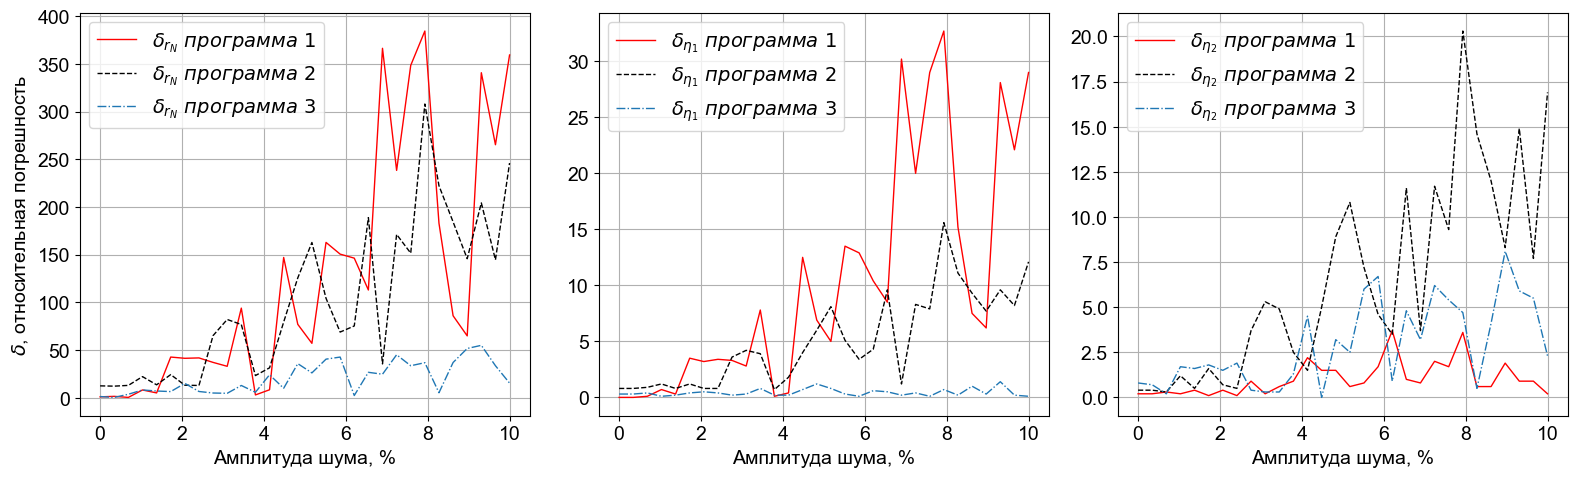

In [16]:
from matplotlib import pyplot as plt

# Визуализация
plt.figure(figsize=(16, 5))

# График давления
plt.subplot(1, 3, 1)
plt.plot(noise_list, calc_error_by_series(res['r_N'][0], well.pump.r_N), 'r', lw=1, label='$\delta_{r_N}\ программа\ 1$')
plt.plot(noise_list, calc_error_by_series(res['r_N'][1], well.pump.r_N), '--k', lw=1, label='$\delta_{r_N}\ программа\ 2$')
plt.plot(noise_list, calc_error_by_series(res['r_N'][2], well.pump.r_N), '-.C0', lw=1, label='$\delta_{r_N}\ программа\ 3$')

plt.xlabel('Амплитуда шума, %')
plt.ylabel('$\delta$, относительная погрешность')
plt.legend()
plt.grid()


# График НЧ шума
plt.subplot(1, 3, 2)
plt.plot(noise_list, calc_error_by_series(res['nn_1'][0], well.pump.nn1), 'r',  label='$\delta_{\eta_1}\ программа\ 1$', lw=1)
plt.plot(noise_list, calc_error_by_series(res['nn_1'][1], well.pump.nn1), '--k', label='$\delta_{\eta_1}\ программа\ 2$', lw=1)
plt.plot(noise_list, calc_error_by_series(res['nn_1'][2], well.pump.nn1), '-.C0', label='$\delta_{\eta_1}\ программа\ 3$', lw=1)

plt.xlabel('Амплитуда шума, %')
plt.legend()
plt.grid()
#plt.ylim(0, 0.8)

# График ВЧ шума
plt.subplot(1, 3, 3)
plt.plot(noise_list, calc_error_by_series(res['nn_2'][0],  well.pump.nn2), 'r', label='$\delta_{\eta_2}\ программа\ 1$', lw=1)
plt.plot(noise_list, calc_error_by_series(res['nn_2'][1],  well.pump.nn2), '--k', label='$\delta_{\eta_2}\ программа\ 2$', lw=1)
plt.plot(noise_list, calc_error_by_series(res['nn_2'][2],  well.pump.nn2), '-.C0', label='$\delta_{\eta_2}\ программа\ 3$', lw=1)
plt.xlabel('Амплитуда шума, %')
plt.legend()
plt.grid()
#plt.ylim(0, 0.8)


plt.tight_layout()
plt.show()

C:\Users\ilyat\AppData\Local\Temp\ipykernel_9792\2779027047.py:15: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()
C:\Users\ilyat\AppData\Local\Temp\ipykernel_9792\2779027047.py:26: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()
C:\Users\ilyat\AppData\Local\Temp\ipykernel_9792\2779027047.py:36: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


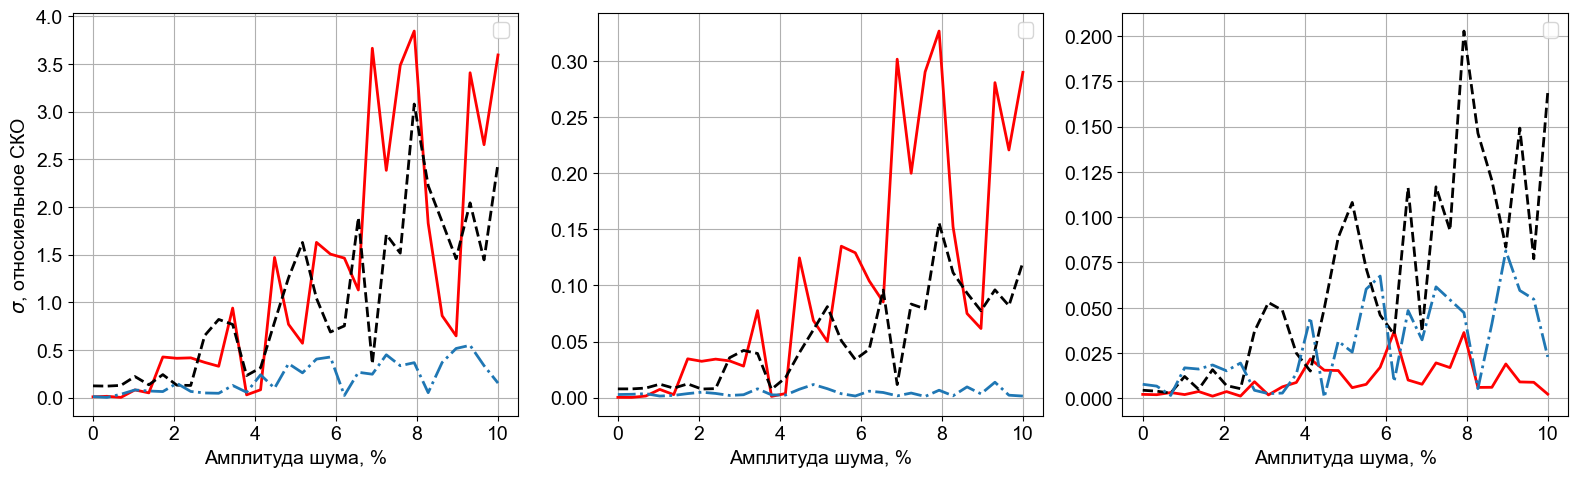

In [17]:
from matplotlib import pyplot as plt


# Визуализация
plt.figure(figsize=(16, 5))

# График давления
plt.subplot(1, 3, 1)
plt.plot(noise_list, calc_rsd_by_series(res['r_N'][0], well.pump.r_N), 'r', lw=2, label='')
plt.plot(noise_list, calc_rsd_by_series(res['r_N'][1], well.pump.r_N), '--k', lw=2, label='')
plt.plot(noise_list, calc_rsd_by_series(res['r_N'][2], well.pump.r_N), '-.C0', lw=2, label='')

plt.xlabel('Амплитуда шума, %')
plt.ylabel('$\sigma$, относиельное СКО')
plt.legend()
plt.grid()


# График НЧ шума
plt.subplot(1, 3, 2)
plt.plot(noise_list, calc_rsd_by_series(res['nn_1'][0], well.pump.nn1), 'r',  label='', lw=2)
plt.plot(noise_list, calc_rsd_by_series(res['nn_1'][1], well.pump.nn1), '--k', label='', lw=2)
plt.plot(noise_list, calc_rsd_by_series(res['nn_1'][2], well.pump.nn1), '-.C0', label='', lw=2)

plt.xlabel('Амплитуда шума, %')
plt.legend()
plt.grid()
#plt.ylim(0, 0.8)

# График ВЧ шума
plt.subplot(1, 3, 3)
plt.plot(noise_list, calc_rsd_by_series(res['nn_2'][0],  well.pump.nn2), 'r', label='', lw=2)
plt.plot(noise_list, calc_rsd_by_series(res['nn_2'][1],  well.pump.nn2), '--k', label='', lw=2)
plt.plot(noise_list, calc_rsd_by_series(res['nn_2'][2],  well.pump.nn2), '-.C0', label='', lw=2)
plt.xlabel('Амплитуда шума, %')
plt.legend()
plt.grid()
#plt.ylim(0, 0.8)


plt.tight_layout()
plt.show()

In [18]:
calc_error(res['r_N'][0][-1], well.pump.r_N)

359.3

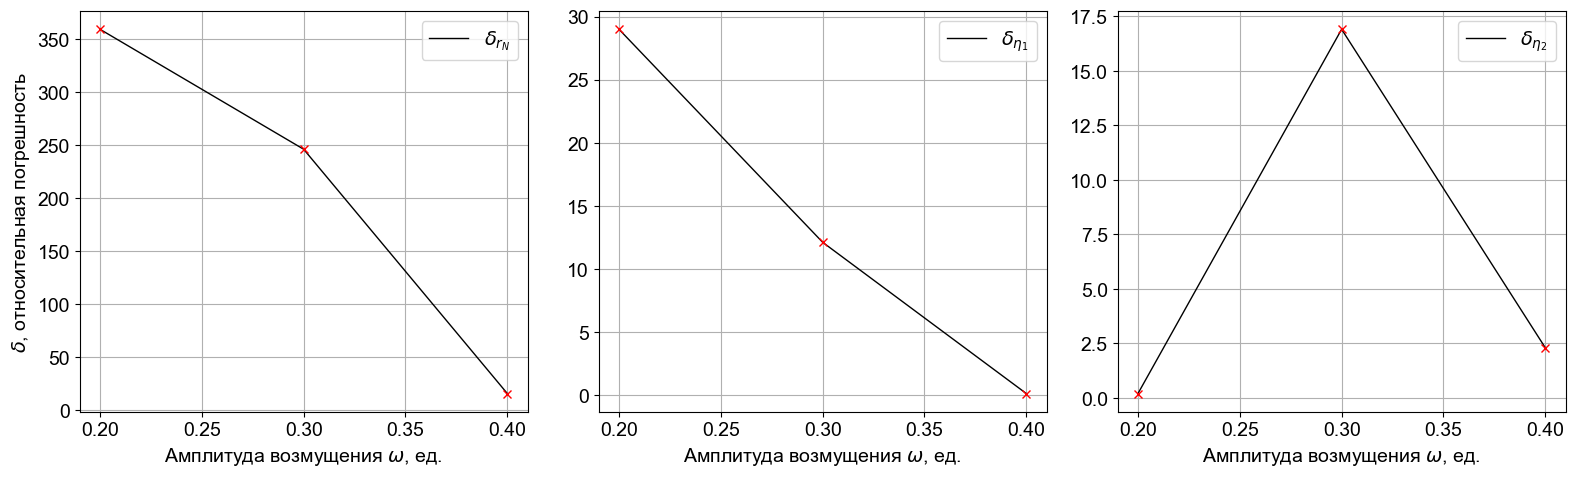

In [19]:
from matplotlib import pyplot as plt

amplitudes = [0.2, 0.3, 0.4,]

# Визуализация
plt.figure(figsize=(16, 5))


# График давления
plt.subplot(1, 3, 1)
erroes = [calc_error(res['r_N'][0][-1], well.pump.r_N), calc_error(res['r_N'][1][-1], well.pump.r_N), calc_error(res['r_N'][2][-1], well.pump.r_N)]
plt.plot(amplitudes, erroes, 'k', lw=1, label='$\delta_{r_N}$')
plt.plot(amplitudes, erroes, 'xr', lw=1, label='')

plt.xlabel('Амплитуда возмущения $\omega$, ед.')
plt.ylabel('$\delta$, относительная погрешность')
plt.legend()
plt.grid()


# График НЧ шума
plt.subplot(1, 3, 2)
erroes = [calc_error(res['nn_1'][0][-1], well.pump.nn1), calc_error(res['nn_1'][1][-1], well.pump.nn1), calc_error(res['nn_1'][2][-1], well.pump.nn1)]
plt.plot(amplitudes, erroes, 'k', lw=1, label='$\delta_{\eta_1}$')
plt.plot(amplitudes, erroes, 'xr', lw=1, label='')

plt.xlabel('Амплитуда возмущения $\omega$, ед.')
plt.legend()
plt.grid()
#plt.ylim(0, 0.8)

# График ВЧ шума
plt.subplot(1, 3, 3)
erroes = [calc_error(res['nn_2'][0][-1], well.pump.nn2), calc_error(res['nn_2'][1][-1], well.pump.nn2), calc_error(res['nn_2'][2][-1], well.pump.nn2)]
plt.plot(amplitudes, erroes, 'k', lw=1, label='$\delta_{\eta_2}$')
plt.plot(amplitudes, erroes, 'xr', lw=1, label='')

plt.xlabel('Амплитуда возмущения $\omega$, ед.')
plt.legend()
plt.grid()
#plt.ylim(0, 0.8)


plt.tight_layout()
plt.show()